In [2]:
import sys # Imports Python's system module- It allows you to interact with the Python interpreter, such as modifying where Python looks for files to import.
sys.path.append("..") # Add parent folder so imports like utils.py work
import warnings # This imports Python's warnings module.
warnings.filterwarnings("ignore") # Ignore all warning messages.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils import load_raw_data
import seaborn as sns



==========================================================
#### STEP 1: EXPLORATORY DATA ANALYSIS (EDA)
#### YouTube Comments Sentiment Dataset
==========================================================

 ------------------------------------------------------------------
 1. Load data
 ------------------------------------------------------------------

In [3]:
df = load_raw_data("../data/comments.csv")
print("Shape:", df.shape)
df.head()

Shape: (103482, 12)


,CommentID,VideoID,VideoTitle,AuthorName,AuthorChannelID,CommentText,Sentiment,Likes,Replies,PublishedAt,CountryCode,CategoryID
0,UgyRjrEdJIPrf68uND14AaABAg,mcY4M9gjtsI,They killed my friend.#tales #movie #shorts,@OneWhoWandered,UC_-UEXaBL1dqqUPGkDll49A,Anyone know what movie this is?,Neutral,0,2,15-01-2025 00:54,NZ,1
1,UgxXxEIySAwnMNw8D7N4AaABAg,2vuXcw9SZbA,Man Utd conceding first penalty at home in yea...,@chiefvon3068,UCZ1LcZESjYqzaQRhjdZJFwg,The fact they're holding each other back while...,Positive,0,0,13-01-2025 23:51,AU,17
2,UgxB0jh2Ur41mcXr5IB4AaABAg,papg2tsoFzg,Welcome to Javascript Course,@Abdulla-ip8qr,UCWBK35w5Swy1iF5xIbEyw3A,waiting next video will be?,Neutral,1,0,06-07-2020 13:18,IN,27
3,UgwMOh95MfK0GuXLLrF4AaABAg,31KTdfRH6nY,Building web applications in Java with Spring ...,@finnianthehuman,UCwQ2Z03nOcMxWozBb_Cv66w,Thanks for the great video. I don't understand...,Neutral,0,1,18-09-2024 12:04,US,27
4,UgxJuUe5ysG8OSbABAl4AaABAg,#NAME?,After a new engine her car dies on her way hom...,@ryoutubeplaylistb6137,UCTTcJ0tsAKQokmHB2qVb1qQ,Good person helping good people. This is how i...,Positive,3,1,10-01-2025 19:39,US,2


 ------------------------------------------------------------------
 2. Basic info / missing values / duplicates
 ------------------------------------------------------------------

In [4]:
print(df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate comment texts:", df["CommentText"].duplicated().sum())

CommentID          object
VideoID            object
VideoTitle         object
AuthorName         object
AuthorChannelID    object
CommentText        object
Sentiment          object
Likes               int64
Replies             int64
PublishedAt        object
CountryCode        object
CategoryID          int64
dtype: object

Missing values:
 CommentID           0
VideoID             0
VideoTitle          0
AuthorName         71
AuthorChannelID     0
CommentText         0
Sentiment           0
Likes               0
Replies             0
PublishedAt         0
CountryCode         0
CategoryID          0
dtype: int64

Duplicate rows: 0
Duplicate comment texts: 2152


 ------------------------------------------------------------------
 3. Target variable distribution (Sentiment)
 ------------------------------------------------------------------

In [5]:
print(df["Sentiment"].value_counts())
print(df["Sentiment"].value_counts(normalize=True))

Sentiment
Negative    35073
Positive    34308
Neutral     34101
Name: count, dtype: int64
Sentiment
Negative    0.338929
Positive    0.331536
Neutral     0.329536
Name: proportion, dtype: float64


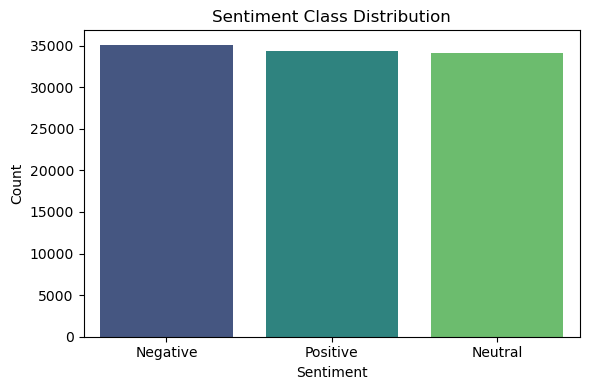

In [6]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x="Sentiment",
    order=df["Sentiment"].value_counts().index,
    palette="viridis"
)

plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

 ------------------------------------------------------------------
 4. Text length analysis
 ------------------------------------------------------------------

       CommentLength_chars  CommentLength_words
count         103482.00000        103482.000000
mean             107.48077            19.413550
std              177.30163            30.194223
min                1.00000             1.000000
25%               34.00000             6.000000
50%               65.00000            12.000000
75%              123.00000            22.000000
max             9997.00000          1655.000000


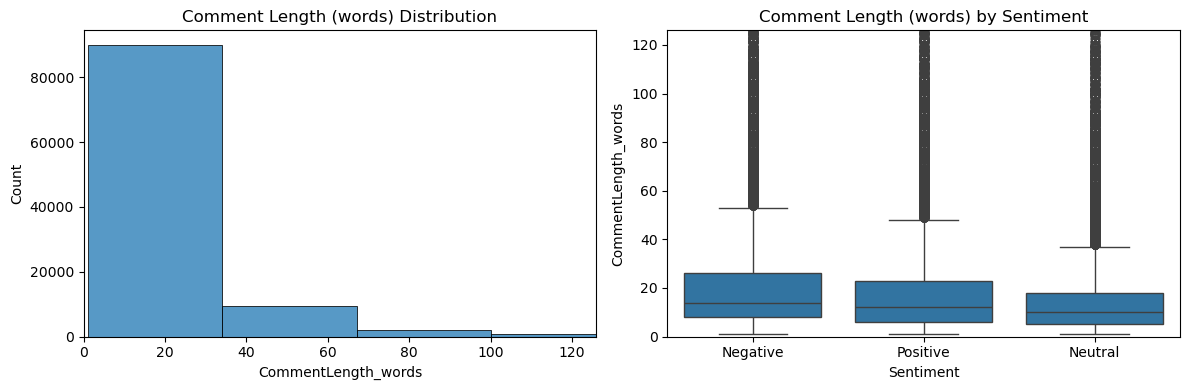

In [8]:
df["CommentLength_chars"] = df["CommentText"].astype(str).str.len()
df["CommentLength_words"] = df["CommentText"].astype(str).str.split().str.len()

print(df[["CommentLength_chars", "CommentLength_words"]].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["CommentLength_words"], bins=50, ax=axes[0])
axes[0].set_title("Comment Length (words) Distribution")
axes[0].set_xlim(0, df["CommentLength_words"].quantile(0.99))

sns.boxplot(data=df, x="Sentiment", y="CommentLength_words",
            order=df["Sentiment"].value_counts().index, ax=axes[1])
axes[1].set_title("Comment Length (words) by Sentiment")
axes[1].set_ylim(0, df["CommentLength_words"].quantile(0.99))

plt.tight_layout()
plt.show()

 ------------------------------------------------------------------
 5. Engagement (Likes & Replies) by sentiment
 ------------------------------------------------------------------

             Likes                                                         \
             count        mean          std  min  25%  50%  75%       max   
Sentiment                                                                   
Negative   35073.0   60.854903  1683.674228  0.0  0.0  0.0  1.0  275849.0   
Neutral    34101.0   95.283863  1453.341718  0.0  0.0  0.0  1.0  117177.0   
Positive   34308.0  155.188761  1736.068025  0.0  0.0  1.0  9.0  123650.0   

           Replies                                                  
             count      mean        std  min  25%  50%  75%    max  
Sentiment                                                           
Negative   35073.0  1.986542  13.382563  0.0  0.0  0.0  0.0  720.0  
Neutral    34101.0  1.726254  14.108484  0.0  0.0  0.0  0.0  750.0  
Positive   34308.0  2.330768  13.560560  0.0  0.0  0.0  0.0  692.0  


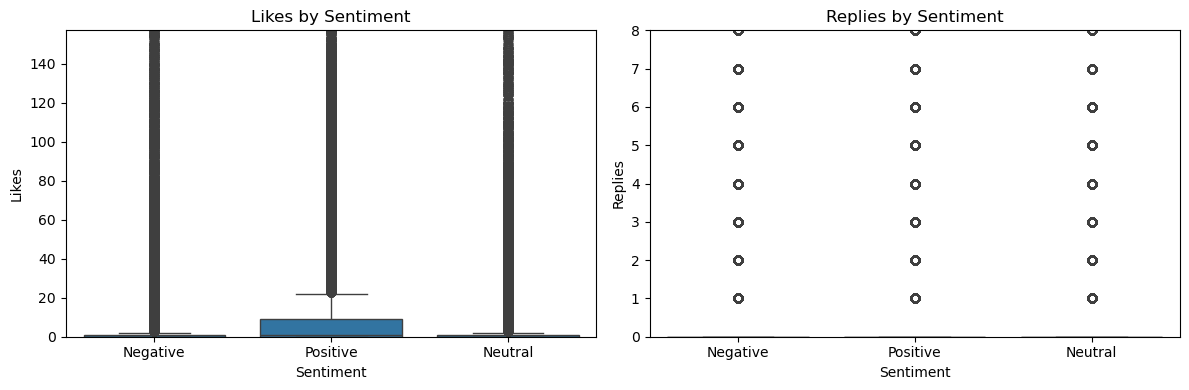

In [9]:
print(df.groupby("Sentiment")[["Likes", "Replies"]].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x="Sentiment", y="Likes",
            order=df["Sentiment"].value_counts().index, ax=axes[0])
axes[0].set_title("Likes by Sentiment")
axes[0].set_ylim(0, df["Likes"].quantile(0.95))

sns.boxplot(data=df, x="Sentiment", y="Replies",
            order=df["Sentiment"].value_counts().index, ax=axes[1])
axes[1].set_title("Replies by Sentiment")
axes[1].set_ylim(0, df["Replies"].quantile(0.95))

plt.tight_layout()
plt.show()

 ------------------------------------------------------------------
 6. Temporal trends
 ------------------------------------------------------------------

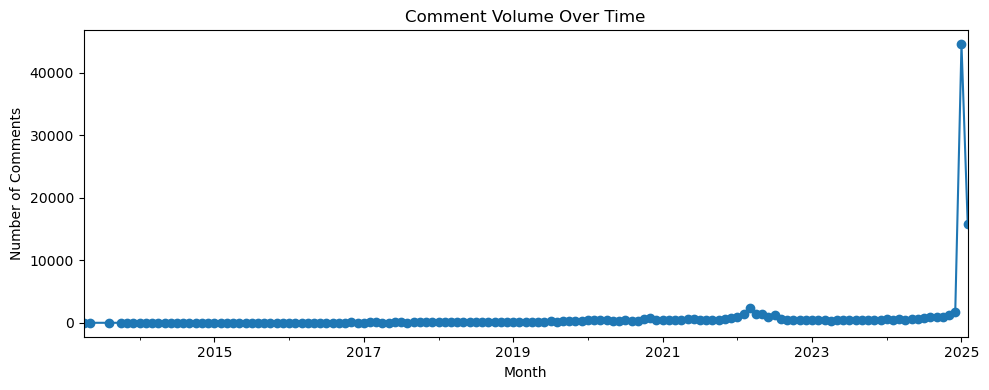

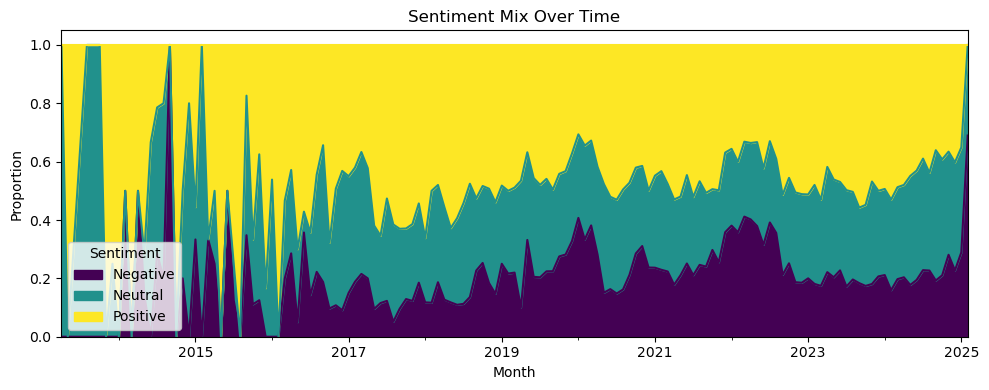

In [10]:
df["PublishedAt_dt"] = pd.to_datetime(df["PublishedAt"], format="%d-%m-%Y %H:%M", errors="coerce")
df["PublishedMonth"] = df["PublishedAt_dt"].dt.to_period("M")

monthly_counts = df.groupby("PublishedMonth").size()

plt.figure(figsize=(10, 4))
monthly_counts.plot(kind="line", marker="o")
plt.title("Comment Volume Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Comments")
plt.tight_layout()
plt.show()

monthly_sentiment = df.groupby(["PublishedMonth", "Sentiment"]).size().unstack(fill_value=0)
monthly_sentiment_pct = monthly_sentiment.div(monthly_sentiment.sum(axis=1), axis=0)

monthly_sentiment_pct.plot(kind="area", stacked=True, figsize=(10, 4), colormap="viridis")
plt.title("Sentiment Mix Over Time")
plt.xlabel("Month")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

 ------------------------------------------------------------------
 7. Geographic & category distribution
 ------------------------------------------------------------------

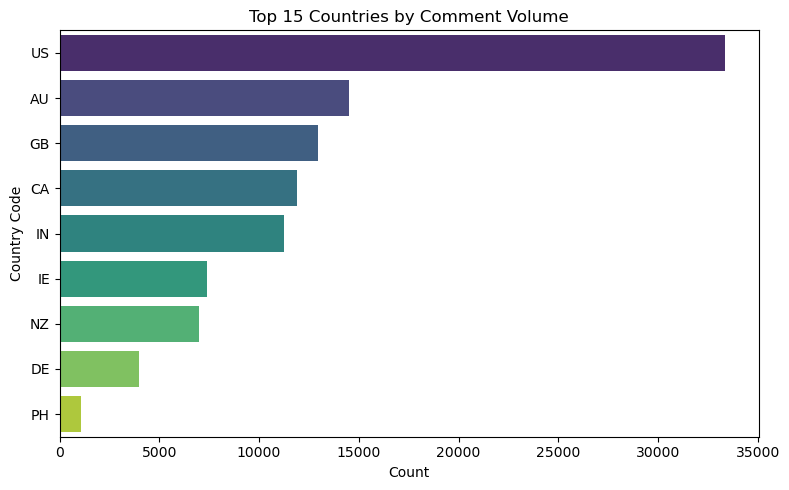

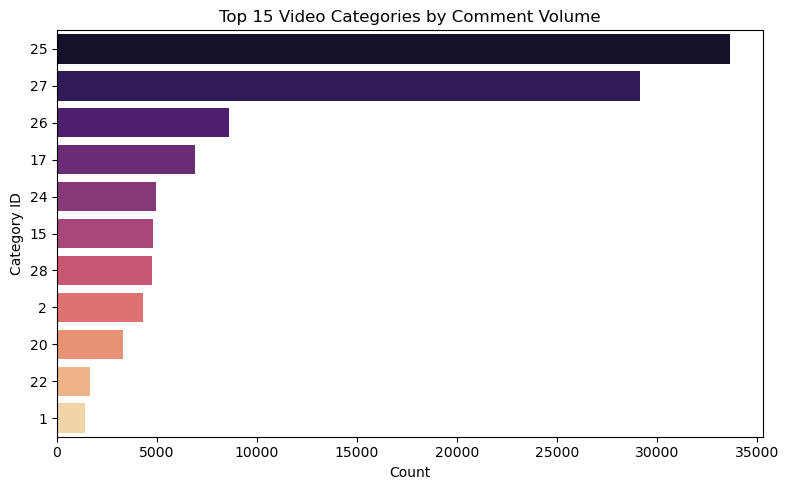

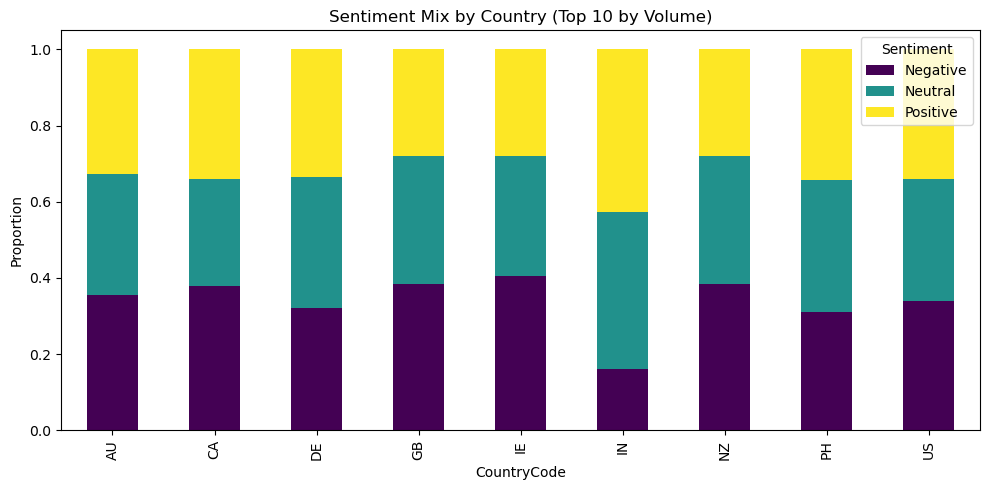

In [11]:
top_countries = df["CountryCode"].value_counts().head(15)
plt.figure(figsize=(8, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis")
plt.title("Top 15 Countries by Comment Volume")
plt.xlabel("Count")
plt.ylabel("Country Code")
plt.tight_layout()
plt.show()

top_cats = df["CategoryID"].value_counts().head(15)
plt.figure(figsize=(8, 5))
sns.barplot(x=top_cats.values, y=top_cats.index.astype(str), palette="magma")
plt.title("Top 15 Video Categories by Comment Volume")
plt.xlabel("Count")
plt.ylabel("Category ID")
plt.tight_layout()
plt.show()

# sentiment mix for the 10 most common countries
top10_countries = df["CountryCode"].value_counts().head(10).index
country_sentiment = (df[df["CountryCode"].isin(top10_countries)]
                      .groupby(["CountryCode", "Sentiment"]).size()
                      .unstack(fill_value=0))
country_sentiment_pct = country_sentiment.div(country_sentiment.sum(axis=1), axis=0)

country_sentiment_pct.plot(kind="bar", stacked=True, figsize=(10, 5), colormap="viridis")
plt.title("Sentiment Mix by Country (Top 10 by Volume)")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

 ------------------------------------------------------------------
 8. Text content patterns (top words per sentiment class)
 ------------------------------------------------------------------

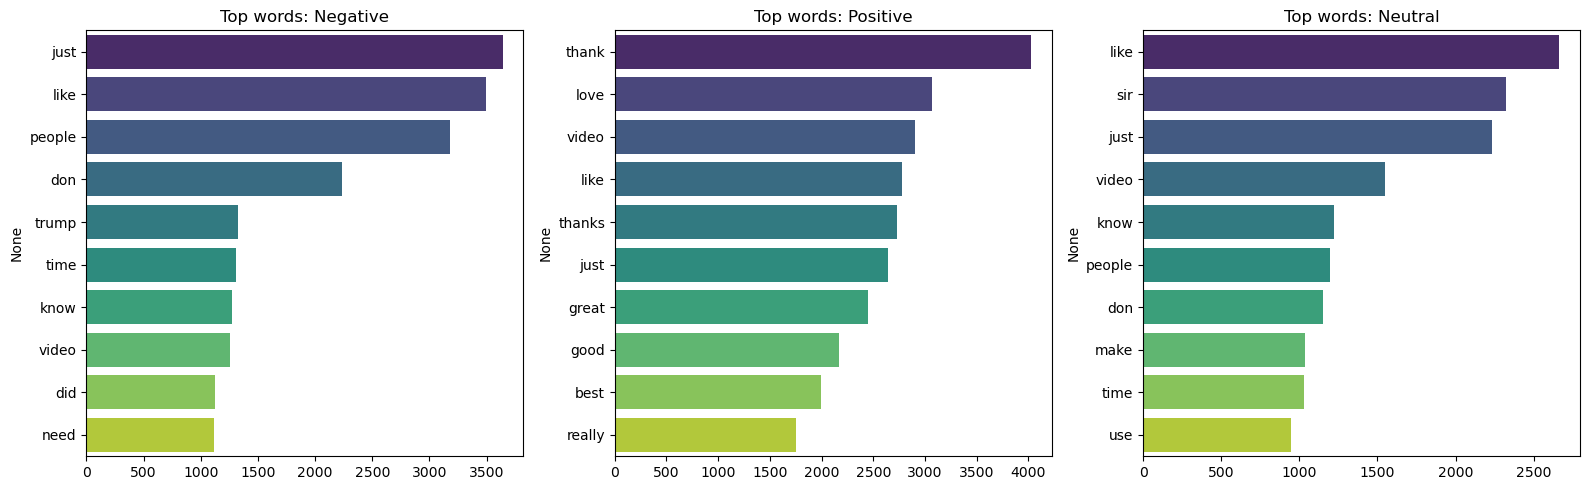

In [12]:
from sklearn.feature_extraction.text import CountVectorizer

def top_ngrams(texts, n_top=15, ngram_range=(1, 1)):
    vec = CountVectorizer(stop_words="english", ngram_range=ngram_range, min_df=5)
    X = vec.fit_transform(texts.astype(str))
    counts = X.sum(axis=0).A1
    vocab = vec.get_feature_names_out()
    return pd.Series(counts, index=vocab).sort_values(ascending=False).head(n_top)

fig, axes = plt.subplots(1, len(df["Sentiment"].unique()), figsize=(16, 5))
for ax, sentiment in zip(axes, df["Sentiment"].value_counts().index):
    subset = df.loc[df["Sentiment"] == sentiment, "CommentText"]
    top_words = top_ngrams(subset, n_top=10)
    sns.barplot(x=top_words.values, y=top_words.index, ax=ax, palette="viridis")
    ax.set_title(f"Top words: {sentiment}")

plt.tight_layout()
plt.show()

 ------------------------------------------------------------------
 9. Correlation between numeric features
 ------------------------------------------------------------------

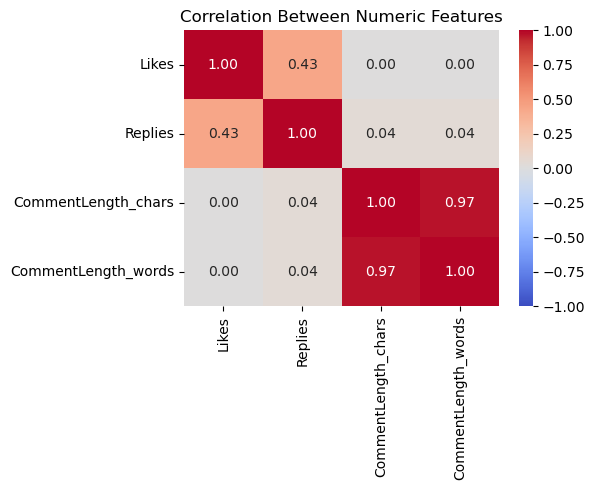

In [13]:
numeric_cols = ["Likes", "Replies", "CommentLength_chars", "CommentLength_words"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Between Numeric Features")
plt.tight_layout()
plt.show()

 ------------------------------------------------------------------
 10. EDA summary
 ------------------------------------------------------------------

Key observations to fill in after running the notebook on the full dataset:
- Class balance: note the relative sizes of Positive / Negative / Neutral and whether resampling or class weighting is needed.
- Comment length: note whether length differs meaningfully by sentiment (useful as a feature).
- Engagement: note whether Likes/Replies correlate with sentiment.
- Time: note any drift in sentiment mix over time (relevant for train/test split strategy).
- Geography/category: note whether sentiment distribution varies enough by country or category to warrant stratification.
- Vocabulary: note dataset-specific tokens (slang, Hinglish terms, emoji-derived tokens) surfaced by the top-words analysis that should inform preprocessing/translation steps downstream.